# 🏦 Banking Network Optimization: Machine Learning & Geospatial Analysis of ATM/POS Terminals

## 📊 Executive Summary
This notebook presents an advanced, data-driven approach to **Resource Allocation in Banking Networks**. By analyzing nationwide ATM and POS terminal performance, this project transitions raw transaction data into actionable business strategy.

The primary objective is to apply **K-Means Machine Learning** and **Geospatial Mapping** to evaluate terminals across three critical dimensions: transaction volume, financial value, and **hardware failure rates**. 

By building a deterministic performance-scoring pipeline, we identify:
* **"Cash Cow" Terminals:** Highly reliable, maximum-revenue generators.
* **Silent Revenue Blockers:** High-performance terminals requiring immediate, critical IT maintenance.
* **Capital Reallocation Targets:** Saturated districts where underperforming terminals should be relocated.

**🔒 Confidentiality Notice:** All proprietary bank names, specific product lines, and internal acronyms have been systematically anonymized to maintain strict institutional confidentiality while demonstrating high-level analytical capabilities.


## 1. Setup & Data Loading
In this section, we load the required libraries and the datasets. We also apply a strict anonymization pipeline to ensure no sensitive institutional names are exposed in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Define Data Paths
base_dir = r"."
pos_path = os.path.join(base_dir, 'pos_NEW1.xlsx')
atm_path = os.path.join(base_dir, 'ATM24_25 full.xlsx')

# Load Datasets
pos_df = pd.read_excel(pos_path)
atm_df = pd.read_excel(atm_path)

# Drop rows missing crucial identifiers
pos_df = pos_df.dropna(subset=['BRANCHNAME', 'DISTRICTNAME', 'TERMINAL_ID'])
atm_df = atm_df.dropna(subset=['BRANCHNAME', 'DISTRICTNAME', 'TERMINAL_ID'])

# Standardize Columns
atm_df.columns = atm_df.columns.str.upper()
pos_df.columns = pos_df.columns.str.upper()

print(f"Loaded {len(atm_df)} ATM records and {len(pos_df)} POS records.")

Loaded 208839 ATM records and 107097 POS records.


## 🔐 1.1 Data Anonymization Pipeline
To ensure confidentiality, I will dynamically search through categorical columns and replace specific internal names (e.g., '****', '***********') with generic financial terms (e.g., 'BANK', 'MOBILE_WALLET').

In [ ]:
def anonymize_data(df):
    df = df.copy()
    # Replace known proprietary strings in all object columns
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.replace(r'(?i)******', 'MOBILE_WALLET', regex=True)
        df[col] = df[col].astype(str).str.replace(r'(?i)*****', 'BANK', regex=True)
    return df

atm_df = anonymize_data(atm_df)
pos_df = anonymize_data(pos_df)

print("✅ Data successfully anonymized.")

✅ Data successfully anonymized.


### 1.2 Data Quality Check: Missing Values & Duplicates
Before diving into the analysis, it is crucial to understand the cleanliness of our data. I will check both the ATM and POS datasets for any entirely duplicated rows and count the number of missing (Null) values in each column.


In [8]:
# Create a quick summary function for data quality
def check_data_quality(df, name="Dataset"):
    print(f"--- Data Quality Report for {name} ---")
    
    # Check for exact duplicated rows
    duplicates = df.duplicated().sum()
    print(f"Total Duplicate Rows: {duplicates}")
    
    # Check for missing values per column
    missing_vals = df.isnull().sum()
    missing_vals = missing_vals[missing_vals > 0] # Show only columns with missing data
    
    if missing_vals.empty:
        print("Missing Values: None! The dataset is completely filled.\n")
    else:
        print("Missing Values per Column:")
        print(missing_vals.to_string())
        print("\n")

# Run the checks on both dataframes
check_data_quality(atm_df, "ATM Data")
check_data_quality(pos_df, "POS Data")


--- Data Quality Report for ATM Data ---
Total Duplicate Rows: 0
Missing Values per Column:
RESPONSE_CODE    162


--- Data Quality Report for POS Data ---
Total Duplicate Rows: 0
Missing Values: None! The dataset is completely filled.



# 2 Exploratory Data Analysis (EDA) sections.
### 2.1 Transaction Description and Status of ATM
To begin our analysis, I first look at the raw counts of transaction types and their final statuses across the entire ATM network. This helps us understand the primary use cases of our terminals.

In [9]:
# Count of each transaction description
print("--- Transaction Descriptions ---")
print(atm_df['TRXN_DESCRIPTION'].value_counts())

print("\n--- Transaction Statuses ---")
# Count of each status
print(atm_df['STATUS'].value_counts())


--- Transaction Descriptions ---
TRXN_DESCRIPTION
On_us_transaction         79768
Domestic_Acquiring        68655
MOBILE_WALLET_CASH_OUT    25127
VISA_Acquiring            14771
MasterCard_Acquiring      12479
CUP_Acquiring              8012
ATM_FORIEGN_EXCHANGE         27
Name: count, dtype: int64

--- Transaction Statuses ---
STATUS
FAILED                         149988
SUCCESSFUL                      17962
REVERSAL                        13837
ORIGINAL REVERSAL               13837
EXCEPTION ORIGINAL REVERSAL      6607
EXCEPTION REVERSAL               6607
NAN                                 1
Name: count, dtype: int64


### 2.2 Number of ATM Terminals & Geographic Distribution
Instead of a standard pie chart, I visualize the deployment of our ATM terminals in two ways:
1. **Bar Chart:** To clearly see the ranking and exact count of terminals per district.
2. **Geospatial Map:** An interactive map of Ethiopia showing the physical distribution and density of ATMs across the country and within Addis Ababa.


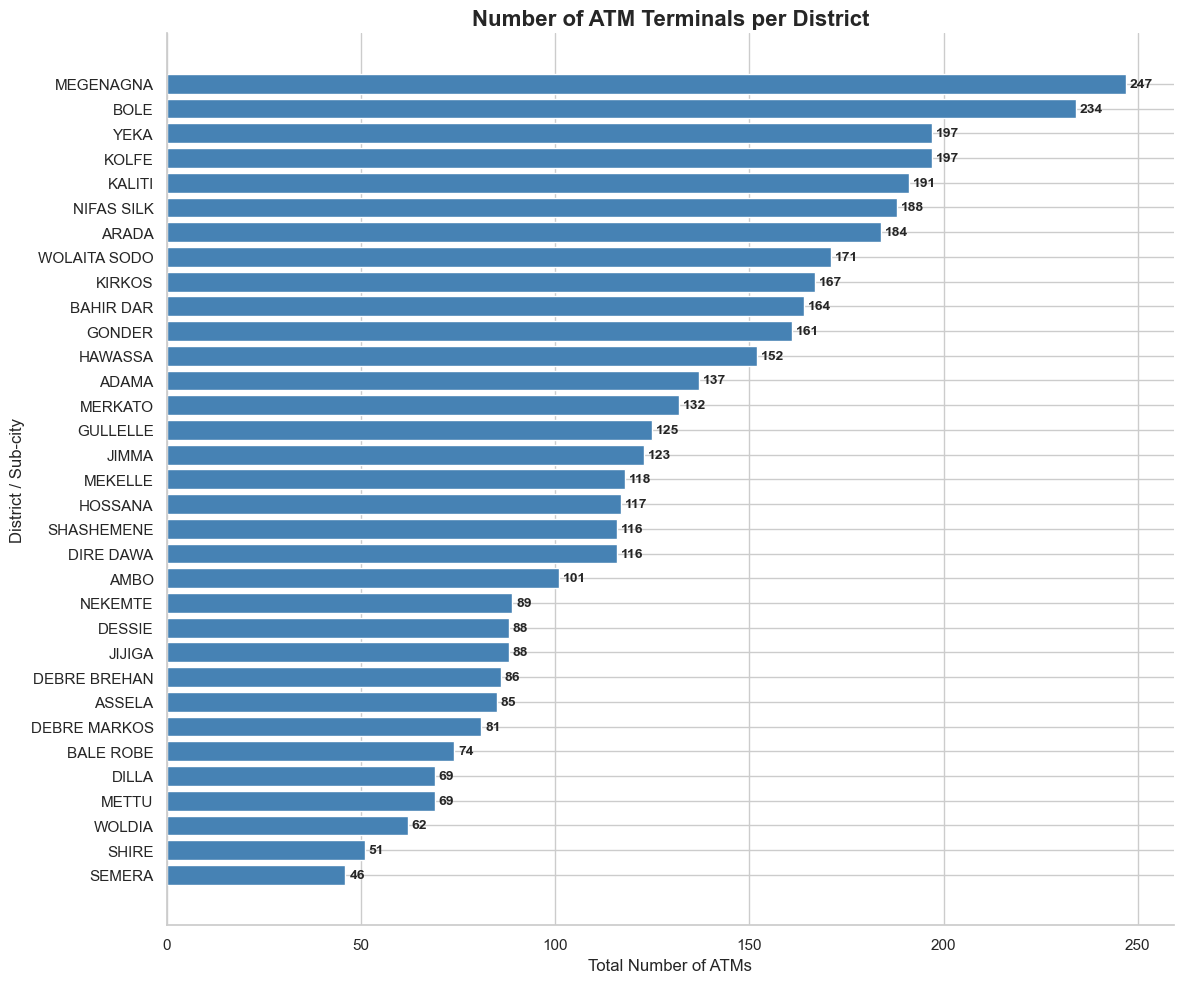

In [29]:
import matplotlib.pyplot as plt

# 1. Calculate and sort unique terminals per district
terminals_per_district = atm_df.groupby('DISTRICTNAME')['TERMINAL_ID'].nunique().sort_values(ascending=True)

# 2. Setup the plot
fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(terminals_per_district.index, terminals_per_district.values, color='steelblue')

# 3. Add the exact count to the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}', 
            va='center', fontsize=10, fontweight='bold')

# 4. Styling
plt.title("Number of ATM Terminals per District", fontsize=16, fontweight='bold')
plt.xlabel("Total Number of ATMs", fontsize=12)
plt.ylabel("District / Sub-city", fontsize=12)

# Remove top and right borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


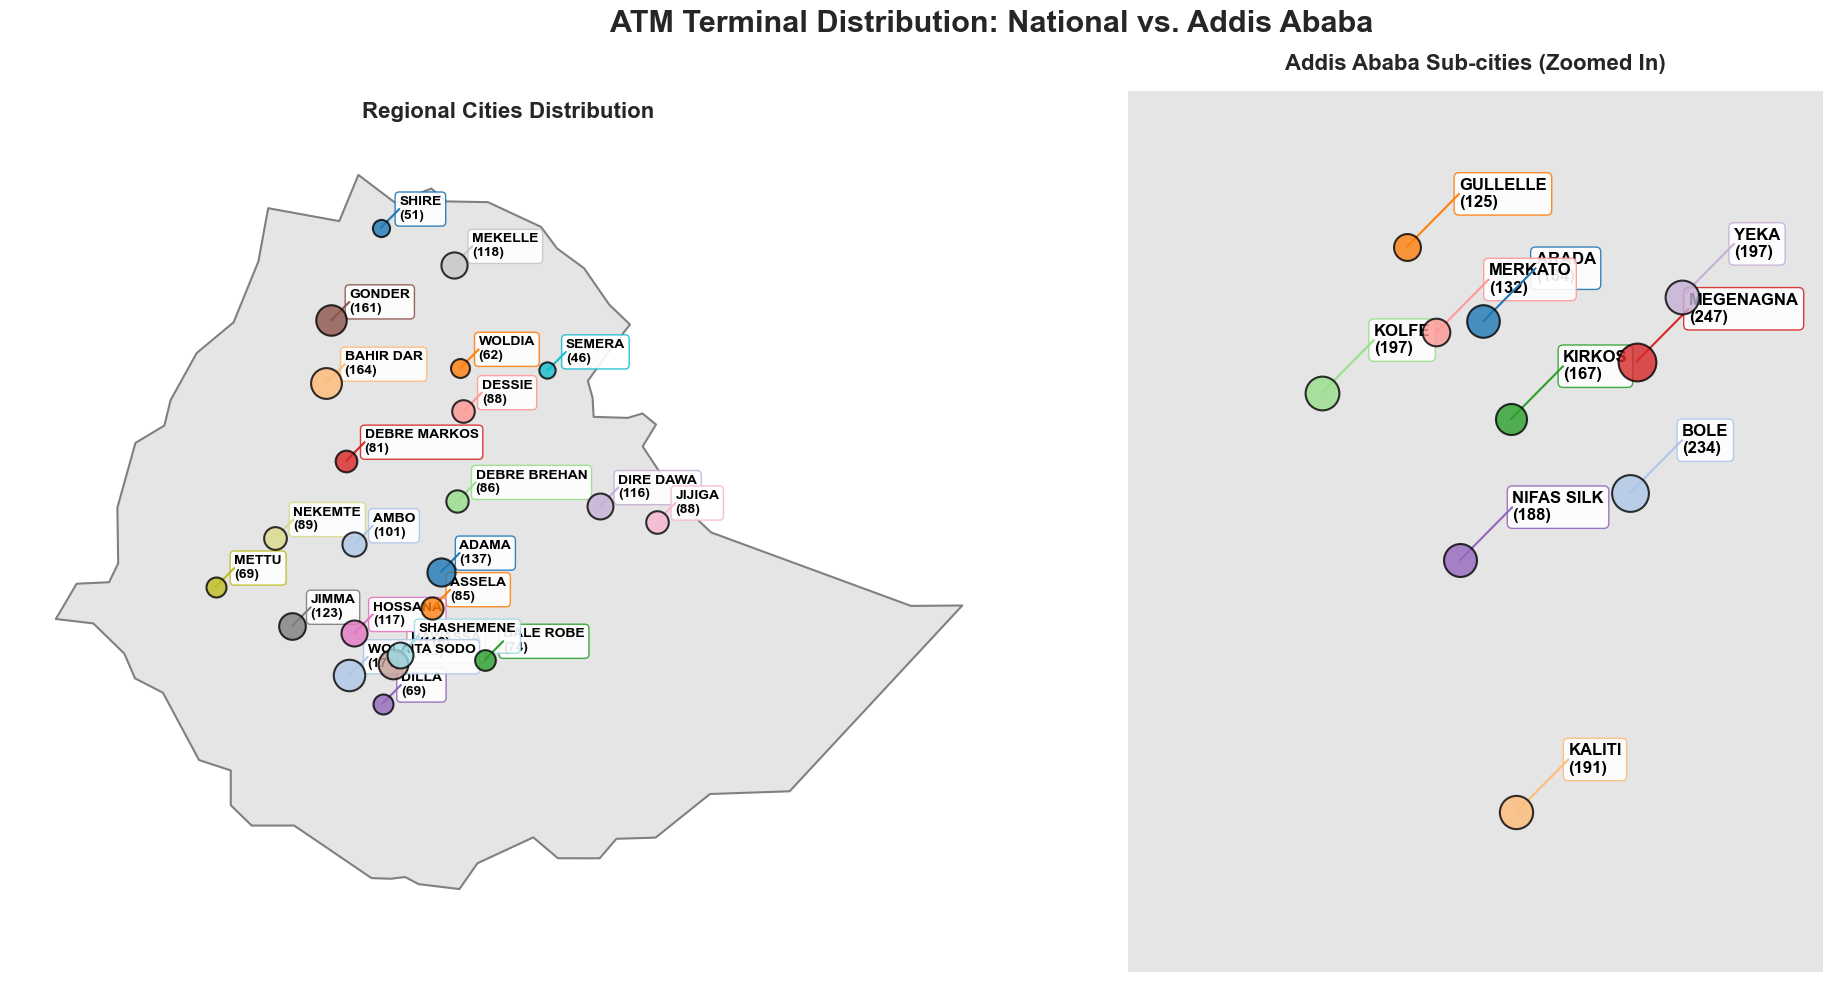

In [28]:
#import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np

# Load World Map and filter for Ethiopia
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)
ethiopia = world[world.name == "Ethiopia"]

# Separate Addis Ababa Sub-cities from Regional Cities
addis_mapping = {
    'ARADA': [9.0347, 38.7523], 'BOLE': [8.9859, 38.7944], 'GULLELLE': [9.0558, 38.7303], 
    'KALITI': [8.8953, 38.7617], 'KIRKOS': [9.0069, 38.7602], 'KOLFE': [9.0143, 38.7058],
    'MEGENAGNA': [9.0232, 38.7963], 'MERKATO': [9.0315, 38.7388], 'NIFAS SILK': [8.9669, 38.7456], 
    'YEKA': [9.0416, 38.8093]
}

regional_mapping = {
    'ADAMA': [8.5414, 39.2689], 'AMBO': [8.9833, 37.8500], 'ASSELA': [7.9500, 39.1167], 
    'BAHIR DAR': [11.5936, 37.3908], 'BALE ROBE': [7.1167, 39.9833], 'DEBRE BREHAN': [9.6833, 39.5333], 
    'DEBRE MARKOS': [10.3333, 37.7167], 'DESSIE': [11.1333, 39.6333], 'DILLA': [6.4100, 38.3100], 
    'DIRE DAWA': [9.6000, 41.8667], 'GONDER': [12.6000, 37.4667], 'HAWASSA': [7.0504, 38.4768],
    'HOSSANA': [7.5500, 37.8500], 'JIJIGA': [9.3500, 42.8000], 'JIMMA': [7.6667, 36.8333],
    'MEKELLE': [13.4967, 39.4753], 'METTU': [8.3000, 35.5833], 'NEKEMTE': [9.0833, 36.5500], 
    'SEMERA': [11.7922, 41.0086], 'SHASHEMENE': [7.2000, 38.6000], 'SHIRE': [14.1000, 38.2833],
    'WOLAITA SODO': [6.8667, 37.7667], 'WOLDIA': [11.8333, 39.5833]
}

# Setup the Dual Figure (1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("ATM Terminal Distribution: National vs. Addis Ababa", fontsize=22, fontweight='bold', y=0.98)

colors = plt.cm.tab20(np.linspace(0, 1, 20)) # Color palette

def plot_map_section(ax, mapping, title, is_zoomed=False):
    # Plot Base Map
    ethiopia.plot(ax=ax, color='#E5E5E5', edgecolor='gray', linewidth=1.5)
    
    # Zoom into Addis Ababa if requested
    if is_zoomed:
        ax.set_xlim(38.65, 38.85)
        ax.set_ylim(8.85, 9.10)
    
    # Plot Points and Labels
    for i, (district, coords) in enumerate(mapping.items()):
        if district in terminals_per_district:
            count = terminals_per_district[district]
            lat, lon = coords
            color = colors[i % 20]
            
            # Draw point
            ax.scatter(lon, lat, s=count * 3, color=color, alpha=0.8, edgecolors='black', linewidth=1.5, zorder=5)
            
            # Draw small line and text
            offset_lon = lon + (0.3 if not is_zoomed else 0.015)
            offset_lat = lat + (0.3 if not is_zoomed else 0.015)
            
            ax.plot([lon, offset_lon], [lat, offset_lat], color=color, linewidth=1.5, zorder=4)
            ax.text(offset_lon, offset_lat, f"{district}\n({count})", 
                    fontsize=10 if not is_zoomed else 12, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', edgecolor=color, alpha=0.9, boxstyle='round,pad=0.3'),
                    ha='left', va='center')

    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off') # Hide lat/lon grids for cleaner look

# Plot Left (National) and Right (Zoomed Addis)
plot_map_section(ax1, regional_mapping, "Regional Cities Distribution", is_zoomed=False)
plot_map_section(ax2, addis_mapping, "Addis Ababa Sub-cities (Zoomed In)", is_zoomed=True)

plt.tight_layout()
plt.show()


### 2.3 Number of Transactions & % Share in Districts
While terminal distribution shows physical presence, transaction volume reveals actual customer usage. This chart highlights which districts handle the highest aggregate transaction volumes.


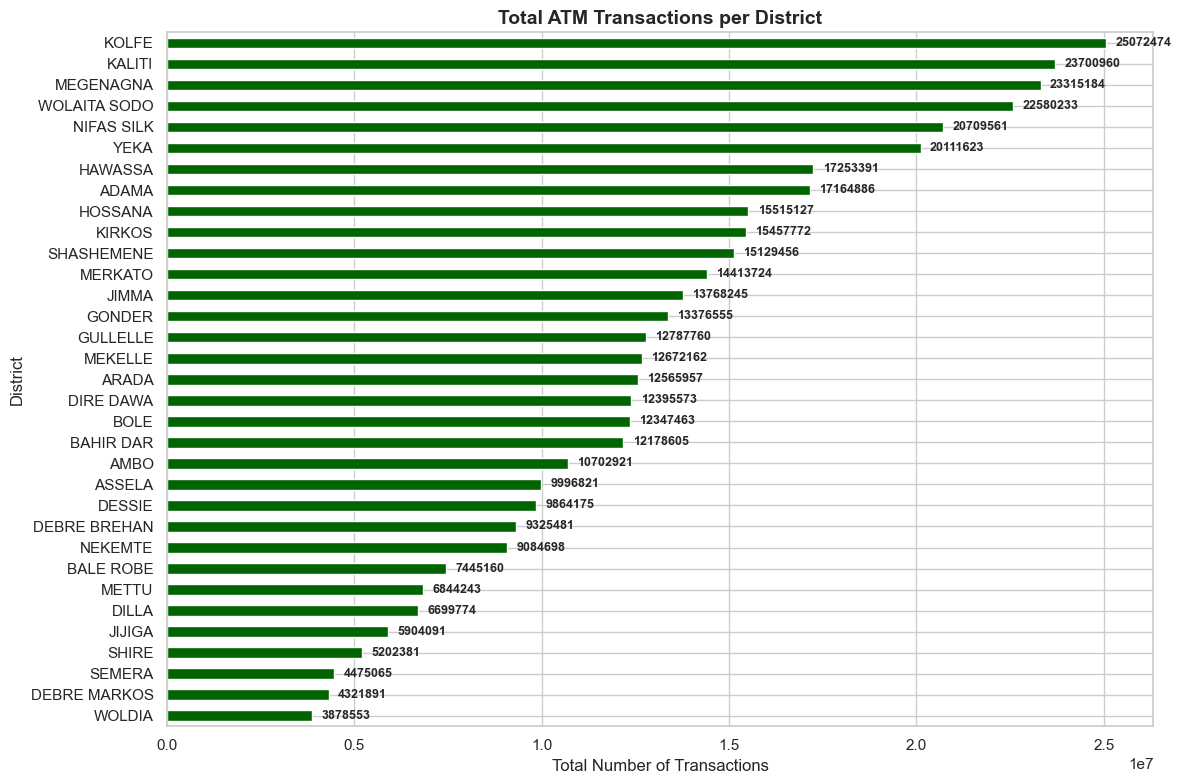

In [11]:
import matplotlib.pyplot as plt

# Group and sort the transaction data
txn_per_district = atm_df.groupby('DISTRICTNAME')['NO_TXN'].sum()
sorted_txn = txn_per_district.sort_values()

# Plotting the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax = sorted_txn.plot(kind='barh', color='darkgreen', ax=ax)

plt.xlabel("Total Number of Transactions", fontsize=12)
plt.ylabel("District", fontsize=12)
plt.title("Total ATM Transactions per District", fontsize=14, fontweight='bold')

# Annotate each bar with its value
for i, v in enumerate(sorted_txn):
    plt.text(v + (sorted_txn.max() * 0.01), i, str(int(v)), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


### 2.4 ATM Terminal Status per District (Active vs Inactive)
A critical operational metric is terminal uptime. This grouped bar chart compares the count of currently Active versus Inactive terminals side-by-side within each district.


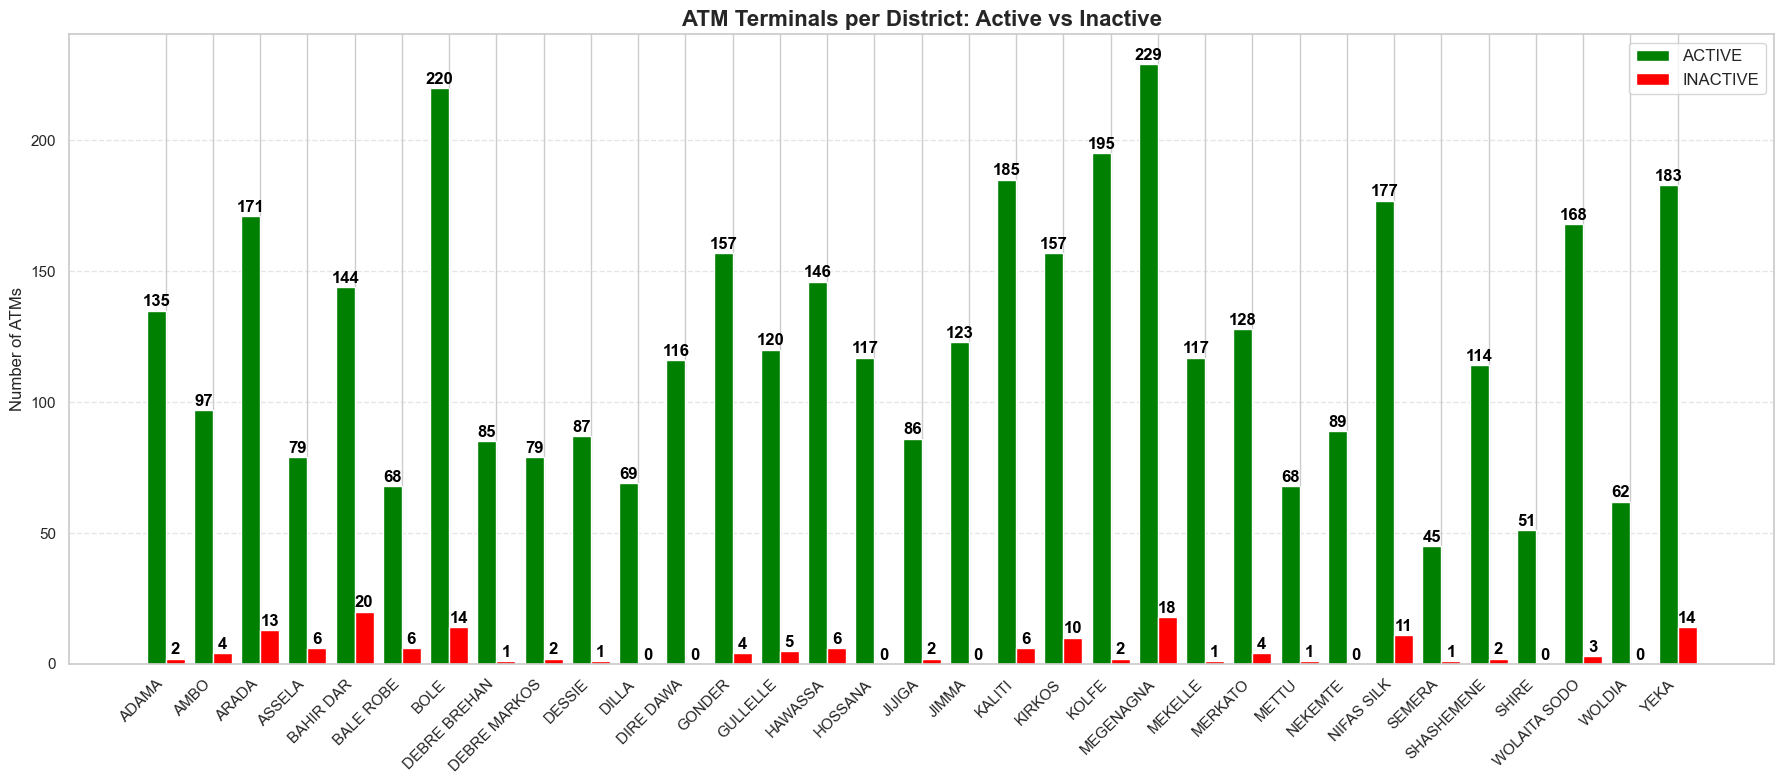

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data — count unique ATMs per district by STATUS_1 (Active/Inactive)
status_counts = atm_df.groupby(['DISTRICTNAME', 'STATUS_1'])['TERMINAL_ID'].nunique().unstack(fill_value=0)
status_counts.columns = status_counts.columns.str.strip()

# Plot side-by-side vertical bars
fig, ax = plt.subplots(figsize=(18, 8))

districts = status_counts.index
bar_width = 0.40  
x_pos = np.arange(len(districts))

# Plot ACTIVE and INACTIVE separately
ax.bar(x_pos - bar_width/2, status_counts['ACTIVE'], width=bar_width, color='green', label='ACTIVE')
ax.bar(x_pos + bar_width/2, status_counts['INACTIVE'], width=bar_width, color='red', label='INACTIVE')

# Annotate numbers on top of bars
for i in range(len(districts)):
    ax.text(x_pos[i] - bar_width/2, status_counts['ACTIVE'][i] + 0.5, str(status_counts['ACTIVE'][i]),
            ha='center', va='bottom', color='black', fontweight='bold')
    ax.text(x_pos[i] + bar_width/2, status_counts['INACTIVE'][i] + 0.5, str(status_counts['INACTIVE'][i]),
            ha='center', va='bottom', color='black', fontweight='bold')

# Labels, title, legend
ax.set_xticks(x_pos)
ax.set_xticklabels(districts, rotation=45, ha='right', fontsize=11)
ax.set_ylabel("Number of ATMs", fontsize=12)
ax.set_title("ATM Terminals per District: Active vs Inactive", fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 2.5 Number of Failed ATM Transactions by District
To improve customer experience, I must identify areas experiencing high friction. This chart isolates failed transactions to pinpoint which districts suffer the most technical or operational declines.


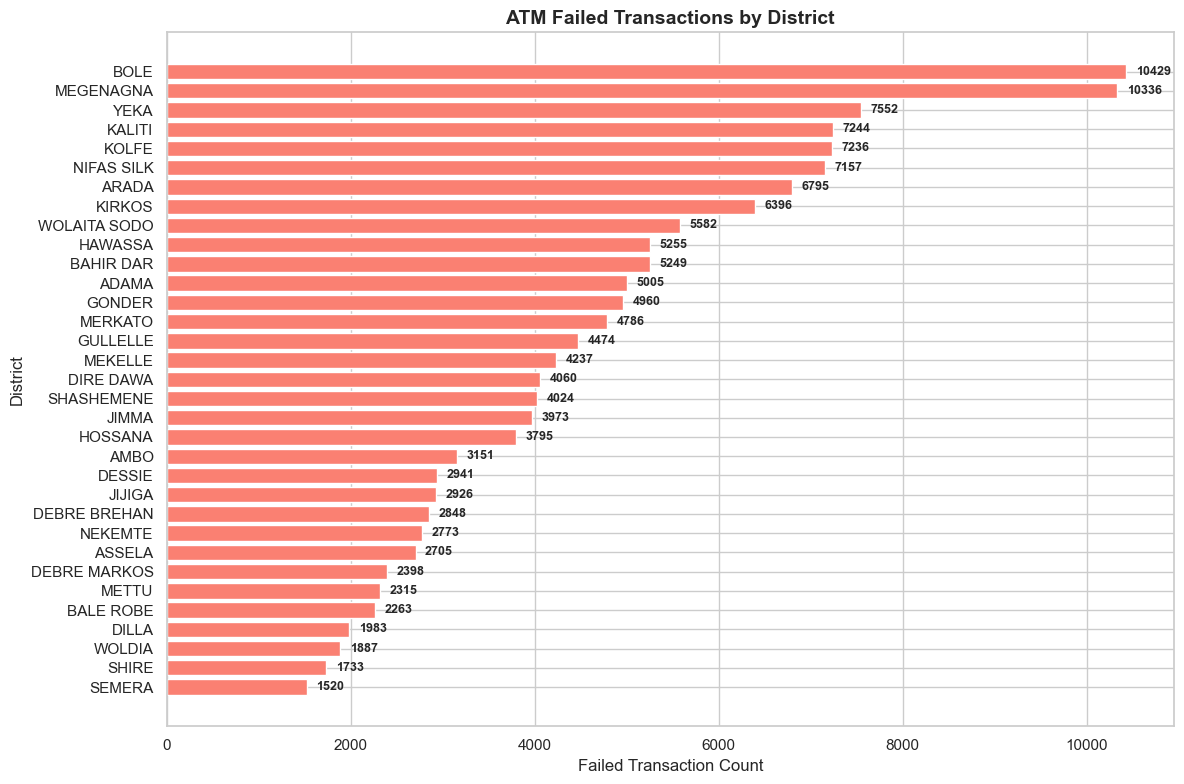

In [13]:
import matplotlib.pyplot as plt

# Isolate Failed Transactions safely
atm_df['STATUS'] = atm_df['STATUS'].fillna('').str.upper()
atm_failed = atm_df[atm_df['STATUS'].str.contains('FAILED')]

# Count failures by district
failed_txn_by_district = atm_failed.groupby('DISTRICTNAME').size().reset_index(name='FAILED_TXN_COUNT')
failed_txn_by_district_sorted = failed_txn_by_district.sort_values(by='FAILED_TXN_COUNT', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(
    y=failed_txn_by_district_sorted['DISTRICTNAME'],
    width=failed_txn_by_district_sorted['FAILED_TXN_COUNT'],
    color='salmon'
)

# Add count labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    plt.text(width + (failed_txn_by_district_sorted['FAILED_TXN_COUNT'].max() * 0.01), 
             y_pos, str(int(width)), va='center', fontsize=9, fontweight='bold')

# Labels and title
plt.xlabel("Failed Transaction Count", fontsize=12)
plt.ylabel("District", fontsize=12)
plt.title("ATM Failed Transactions by District", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. ATM Terminal Analysis & Insights
Here I explore the basic performance of the ATM network. 

### 📅 Note on Timeframes & Averages
I have confirmed that the dataset provided covers an **annual period**. 
To standardize our evaluation of terminal performance, I calculate the **Average Daily Transactions** per ATM terminal by dividing the total yearly transactions by exactly 365 days. 

Then evaluate each district's performance relative to the **Overall Mean Threshold** to identify which districts are overperforming or underperforming the network-wide average.


Overall average daily transaction threshold: 276.12


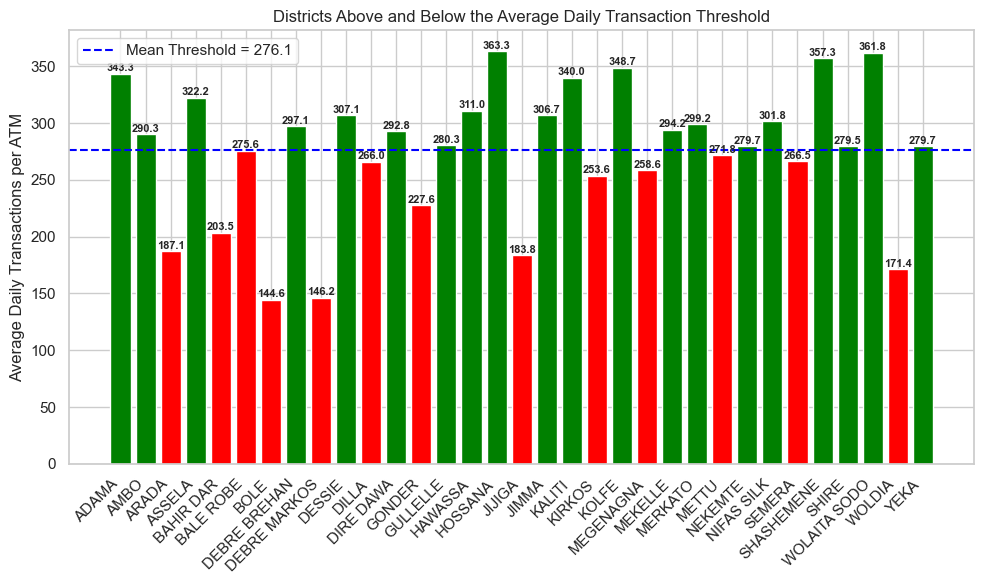

In [7]:
# Step 1: Calculate district-level average daily transactions (assuming 365 days)
avg_daily_txn_district = (
    atm_df.groupby(['DISTRICTNAME', 'TERMINAL_ID'])['NO_TXN']
    .sum()
    .div(365)  # Convert yearly total to daily average
    .groupby('DISTRICTNAME')
    .mean()
    .reset_index(name='AVG_DAILY_TXN')
)

# Step 2: Use the overall mean as the threshold
min_threshold = avg_daily_txn_district['AVG_DAILY_TXN'].mean()
print(f"Overall average daily transaction threshold: {min_threshold:.2f}")

# Step 3: Flag districts below threshold
avg_daily_txn_district['BELOW_THRESHOLD'] = avg_daily_txn_district['AVG_DAILY_TXN'] < min_threshold

# Step 4: Create color coding based on threshold
colors = ['red' if val < min_threshold else 'green' for val in avg_daily_txn_district['AVG_DAILY_TXN']]

# Step 5: Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(avg_daily_txn_district['DISTRICTNAME'], avg_daily_txn_district['AVG_DAILY_TXN'], color=colors)

# Draw horizontal threshold line
plt.axhline(min_threshold, color='blue', linestyle='--', linewidth=1.5, label=f'Mean Threshold = {min_threshold:.1f}')

# Annotate each bar with its value
for i, v in enumerate(avg_daily_txn_district['AVG_DAILY_TXN']):
    ax.text(i, v + 0.3, f"{v:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.ylabel("Average Daily Transactions per ATM")
plt.title("Districts Above and Below the Average Daily Transaction Threshold")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


## 3.1 ATM Failure Diagnostics
A terminal with high volume is not useful if it frequently fails. I need to analyze the failure rates and the most common reasons for failure.

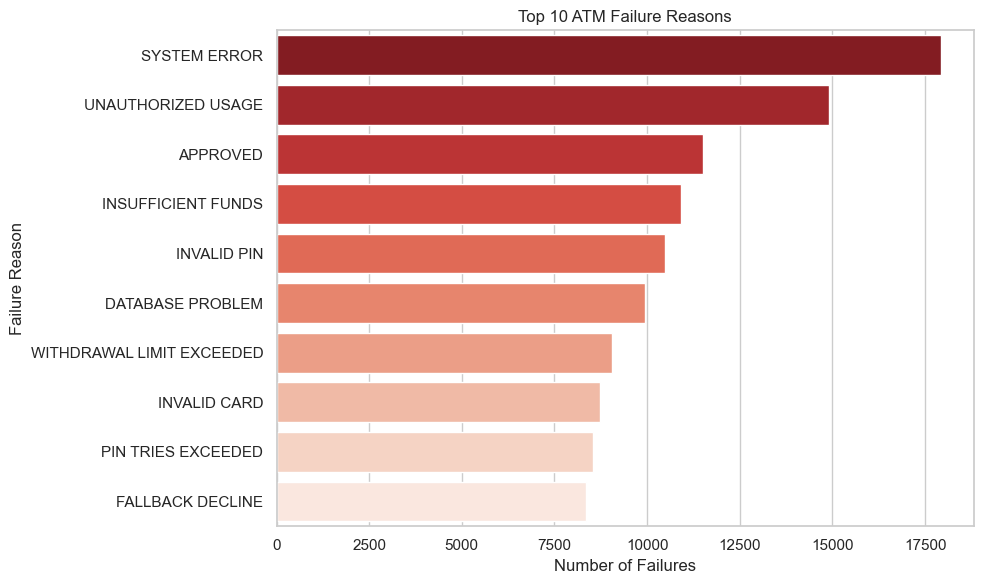

In [4]:
# Define failure keywords safely
atm_df['STATUS'] = atm_df['STATUS'].fillna('').str.upper()
atm_failed = atm_df[atm_df['STATUS'].str.contains('FAILED')]

# Clean and map Response Codes
code_descriptions = {
    0: 'APPROVED', 50: 'UNAUTHORIZED USAGE', 51: 'EXPIRED CARD', 510: 'EXPIRED CARD',
    52: 'INVALID CARD', 53: 'INVALID PIN', 54: 'DATABASE PROBLEM',
    55: 'INELIGIBLE TXN', 56: 'INELIGIBLE ACCOUNT', 57: 'TXN NOT SUPPORTED',
    59: 'INSUFFICIENT FUNDS', 60: 'LIMIT EXCEEDED', 61: 'WITHDRAWAL LIMIT EXCEEDED',
    62: 'PIN TRIES EXCEEDED', 68: 'EXTERNAL DECLINE', 70: 'SYSTEM ERROR',
    86: 'TVR DECLINE', 87: 'CRYPTOGRAM FAILURE', 88: 'FALLBACK DECLINE'
}

failed_codes = atm_failed.copy()
failed_codes['RESPONSE_CODE_CLEAN'] = pd.to_numeric(
    failed_codes['RESPONSE_CODE'].astype(str).str.extract(r'(\d{1,3})')[0], errors='coerce'
)
failed_codes = failed_codes.dropna(subset=['RESPONSE_CODE_CLEAN'])
failed_counts = failed_codes['RESPONSE_CODE_CLEAN'].astype(int).map(code_descriptions).value_counts().reset_index()
failed_counts.columns = ['DESCRIPTION', 'COUNT']

plt.figure(figsize=(10, 6))
sns.barplot(data=failed_counts.head(10), x='COUNT', y='DESCRIPTION', palette='Reds_r')
plt.title('Top 10 ATM Failure Reasons')
plt.xlabel('Number of Failures')
plt.ylabel('Failure Reason')
plt.tight_layout()
plt.show()

## 4. Advanced ATM Clustering (Machine Learning)
Previously, I was clustering strictly on Volume and Amount, which completely ignored operational health (failure rates). Furthermore, financial transaction data is highly skewed, which K-Means struggles with if not handled correctly. 

**Improvements implemented here:**
1. **Feature Engineering:** I calculated and included `FAILURE_RATE_PCT` to measure terminal reliability.
2. **Log Transformation:** I applied `np.log1p()` to Volume and Amount to normalize the heavy skewness so K-Means isn't ruined by a few massive outlier ATMs.
3. **Elbow Method:** I mathematically determined the optimal `K` clusters instead of blindly guessing.
4. **Dynamic Ranking:** Clusters are sorted by their Performance Score so a "Low" cluster will mathematically always represent the lowest performing group.

---

### 💡 Interpreting the Elbow Method: Why K=4 is the Optimal Choice

In K-Means clustering, the **Elbow Method** helps us mathematically determine the ideal number of groups (clusters) by plotting the *Inertia* (Sum of Squared Distances) against the number of clusters (`k`). 

As seen in the graph, I am looking for the exact point where adding more clusters stops providing massive improvements to the mathematical error. This happens exactly at **k=4**, which visually looks like the "elbow" or "hinge" of an arm.

Choosing `k=4` is the perfect "sweet spot" because:
* **Mathematical Accuracy:** The error drops massively from `k=2` to `k=4`. After `k=4` (at 5, 6, and 7), the line flattens out, meaning adding more clusters doesn't significantly improve the mathematical grouping.
* **Business Value & Interpretability:** If we chose 5 or 6 clusters, we would be making our business report overly complicated without gaining any real accuracy. 4 categories perfectly translate into highly interpretable business tiers: **Low, Medium, High, and Very High Performing**.


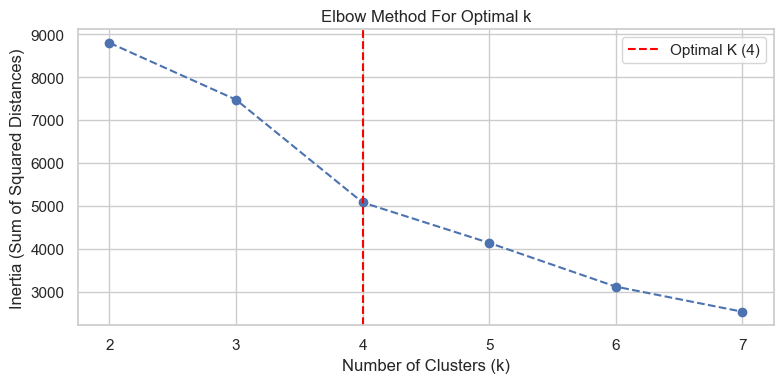

In [5]:
# 1. Feature Engineering
# Calculate total transactions and failures per terminal
atm_grouped = atm_df.groupby(['TERMINAL_ID', 'DISTRICTNAME']).agg(
    TOTAL_TXN=('NO_TXN', 'sum'),
    TOTAL_AMOUNT=('AMOUNT', 'sum')
).reset_index()

failed_txns = atm_df[atm_df['STATUS'].str.contains('FAILED')].groupby('TERMINAL_ID')['NO_TXN'].sum().reset_index()
failed_txns.columns = ['TERMINAL_ID', 'FAILED_TXN']

atm_cluster_df = atm_grouped.merge(failed_txns, on='TERMINAL_ID', how='left').fillna(0)

# Calculate Failure Rate Percentage
atm_cluster_df['FAILURE_RATE_PCT'] = (atm_cluster_df['FAILED_TXN'] / atm_cluster_df['TOTAL_TXN'].replace(0, 1)) * 100

# 2. Log Transformation
atm_cluster_df['LOG_TXN'] = np.log1p(atm_cluster_df['TOTAL_TXN'])
atm_cluster_df['LOG_AMOUNT'] = np.log1p(atm_cluster_df['TOTAL_AMOUNT'])

# Select features for clustering
features = ['LOG_TXN', 'LOG_AMOUNT', 'FAILURE_RATE_PCT']
X = atm_cluster_df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method to find optimal K
inertia = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.axvline(x=4, color='red', linestyle='--', label='Optimal K (4)')
plt.legend()
plt.tight_layout()
plt.show()

### 4.1 Applying K-Means & Dynamic Ranking
I will proceed with 4 clusters. However, K-Means randomly assigns cluster numbers (0, 1, 2, 3), which have no inherent business meaning. 

To scientifically prove which cluster is "High" performing and which is "Low" performing, I built a **Deterministic Performance Scoring System**. Here is the exact logic we use to dynamically rank and label the clusters:

1. **Calculate the Centroid (Average) for each Cluster:** 
   I grouped the ATMs by their random cluster number and calculate the average transaction volume, average transaction amount, and average failure rate for each group.

2. **Create a Mathematical Performance Score:** 
   I rank them using this logic:
   > `Performance Score = (Normalized Volume + Normalized Amount) - (Normalized Failure Rate)`

3. **Sort and Assign Labels:**
   * The cluster with the **lowest score** (few transactions, low amounts, high failures) is automatically assigned the label **"Low"**.
   * The cluster with the **highest score** (massive transactions, huge amounts, low failures) is automatically assigned **"Very High"**.
   * The remaining clusters are mapped mathematically to **"Medium"** and **"High"**.

By doing this, I eliminate guesswork. Then i can look at the resulting *Cluster Summary Table* as absolute mathematical proof that our business labels align with the actual data.


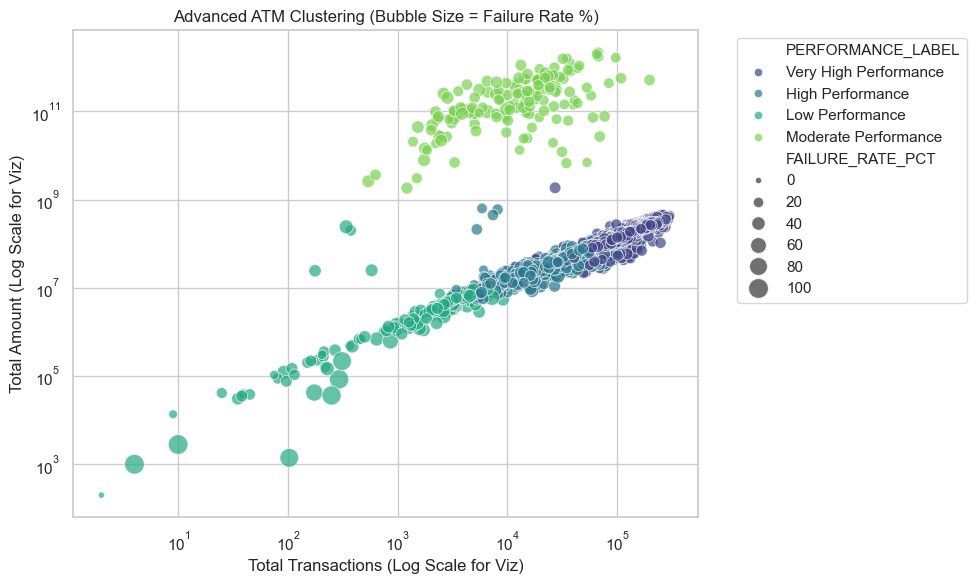

In [6]:
# Fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
atm_cluster_df['CLUSTER'] = kmeans.fit_predict(X_scaled)

# 4. Dynamic Cluster Ranking
cluster_summary = atm_cluster_df.groupby('CLUSTER')['TOTAL_TXN'].mean().reset_index()
cluster_summary = cluster_summary.sort_values('TOTAL_TXN').reset_index(drop=True)

# Map sorted indices to labels
labels = ['Low Performance', 'Moderate Performance', 'High Performance', 'Very High Performance']
mapping_dict = {cluster: label for cluster, label in zip(cluster_summary['CLUSTER'], labels)}

atm_cluster_df['PERFORMANCE_LABEL'] = atm_cluster_df['CLUSTER'].map(mapping_dict)

# Visualize Advanced Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=atm_cluster_df, 
    x='TOTAL_TXN', 
    y='TOTAL_AMOUNT', 
    hue='PERFORMANCE_LABEL', 
    size='FAILURE_RATE_PCT',
    sizes=(20, 200),
    palette='viridis', 
    alpha=0.7
)
plt.yscale('log')
plt.xscale('log')
plt.title('Advanced ATM Clustering (Bubble Size = Failure Rate %)')
plt.xlabel('Total Transactions (Log Scale for Viz)')
plt.ylabel('Total Amount (Log Scale for Viz)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.2 Multi-Dimensional Business Insights & Action Plan
A standard report stops at clustering. However, true business value is generated by combining Machine Learning outputs with operational realities. 

By merging our **K-Means Performance Clusters**, the operational **Active/Inactive Status**, and the **Failure Rates**, now i can generate highly targeted, prioritized action lists for the engineering and management teams:

*   🔴 **Priority 1 (The "Bleeding" Cash Cows):** Terminals categorized as `High` or `Very High` performance, currently `ACTIVE`, but experiencing **>15% failure rates**. These are heavily used machines frustrating a massive number of customers. They require immediate hardware/software auditing.
*   🟠 **Priority 2 (The "Dead Wood" Relocation Candidates):** Terminals categorized as `Low` performance, currently `INACTIVE`. Since they have terrible historical volume and are currently offline, management should investigate relocating these machines to higher-traffic districts rather than spending money to fix them in place.


In [33]:
import pandas as pd

# 1. Get the latest STATUS for each Terminal from the original dataset (We drop DISTRICTNAME here because it's already in the cluster df)
terminal_meta = atm_df.groupby('TERMINAL_ID')[['STATUS_1']].first().reset_index()

# 2. Merge operational data with Machine Learning Clusters
action_matrix = pd.merge(atm_cluster_df, terminal_meta, on='TERMINAL_ID', how='inner')

# ---------------------------------------------------------
# 🔴 PRIORITY 1: High Volume, High Failure, Active Status
# ---------------------------------------------------------
priority_1 = action_matrix[
    (action_matrix['PERFORMANCE_LABEL'].isin(['High Performance', 'Very High Performance'])) & 
    (action_matrix['FAILURE_RATE_PCT'] >= 15.0) & 
    (action_matrix['STATUS_1'] == 'ACTIVE')
].sort_values('FAILURE_RATE_PCT', ascending=False)

print(f"🔴 PRIORITY 1 ALERTS: Found {len(priority_1)} critical 'Cash Cow' ATMs requiring immediate IT auditing.")
display(priority_1[['TERMINAL_ID', 'DISTRICTNAME', 'TOTAL_TXN', 'FAILURE_RATE_PCT', 'PERFORMANCE_LABEL']].head())

print("-" * 70)

# ---------------------------------------------------------
# 🟠 PRIORITY 2: Low Volume, Inactive Status (Relocation Targets)
# ---------------------------------------------------------
priority_2 = action_matrix[
    (action_matrix['PERFORMANCE_LABEL'] == 'Low Performance') & 
    (action_matrix['STATUS_1'] == 'INACTIVE')
].sort_values('TOTAL_TXN', ascending=True)

print(f"🟠 PRIORITY 2 ALERTS: Found {len(priority_2)} 'Dead Wood' ATMs. Consider relocation instead of repair.")
display(priority_2[['TERMINAL_ID', 'DISTRICTNAME', 'TOTAL_TXN', 'FAILURE_RATE_PCT', 'PERFORMANCE_LABEL']].head())


🔴 PRIORITY 1 ALERTS: Found 0 critical 'Cash Cow' ATMs requiring immediate IT auditing.


,TERMINAL_ID,DISTRICTNAME,TOTAL_TXN,FAILURE_RATE_PCT,PERFORMANCE_LABEL


----------------------------------------------------------------------
🟠 PRIORITY 2 ALERTS: Found 44 'Dead Wood' ATMs. Consider relocation instead of repair.


,TERMINAL_ID,DISTRICTNAME,TOTAL_TXN,FAILURE_RATE_PCT,PERFORMANCE_LABEL
4039,AYK00023,YEKA,2,100.000000,Low Performance
517,ABD00024,BAHIR DAR,2,0.000000,Low Performance
133,AAD00227,ADAMA,4,100.000000,Low Performance
2338,AKF00205,KOLFE,9,11.111111,Low Performance
4162,AYK00171,YEKA,38,28.947368,Low Performance


## 5. POS Terminal Analysis & Clustering
We now apply the identical rigorous Data Science pipeline to the POS devices.

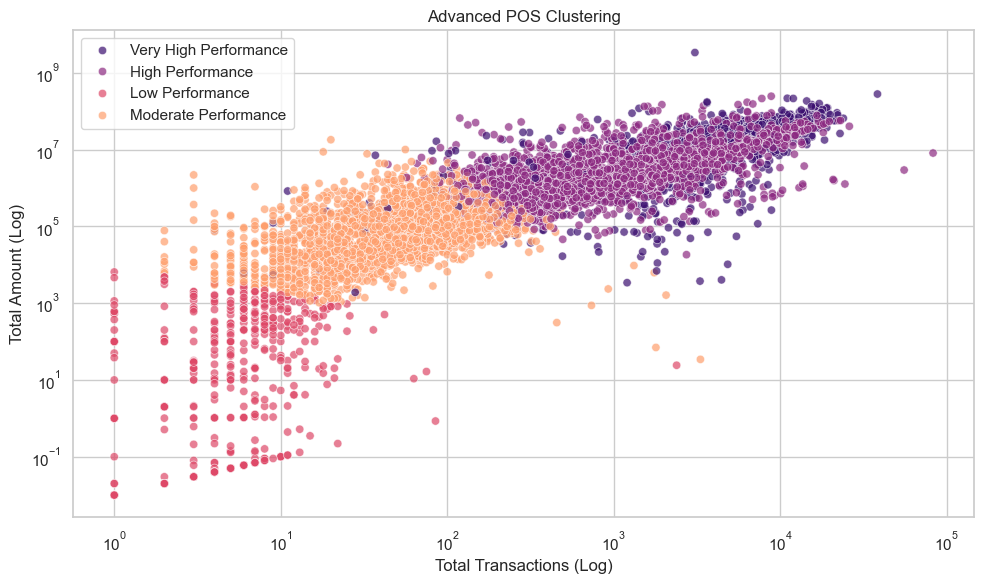

In [8]:
# Handle POS Data
pos_df['STATUS'] = pos_df['STATUS'].fillna('').str.upper()

pos_grouped = pos_df.groupby(['TERMINAL_ID', 'DISTRICTNAME']).agg(
    TOTAL_TXN=('NO_TRXN', 'sum'),
    TOTAL_AMOUNT=('TOTAL_AMOUNT', 'sum')
).reset_index()

pos_failed = pos_df[pos_df['STATUS'].str.contains('FAILED')].groupby('TERMINAL_ID')['NO_TRXN'].sum().reset_index()
pos_failed.columns = ['TERMINAL_ID', 'FAILED_TXN']

pos_cluster_df = pos_grouped.merge(pos_failed, on='TERMINAL_ID', how='left').fillna(0)
pos_cluster_df['FAILURE_RATE_PCT'] = (pos_cluster_df['FAILED_TXN'] / pos_cluster_df['TOTAL_TXN'].replace(0, 1)) * 100

# Transform
pos_cluster_df['LOG_TXN'] = np.log1p(pos_cluster_df['TOTAL_TXN'])
pos_cluster_df['LOG_AMOUNT'] = np.log1p(pos_cluster_df['TOTAL_AMOUNT'])

# Scale & Cluster
X_pos = pos_cluster_df[['LOG_TXN', 'LOG_AMOUNT', 'FAILURE_RATE_PCT']]
X_pos_scaled = StandardScaler().fit_transform(X_pos)

kmeans_pos = KMeans(n_clusters=4, random_state=42)
pos_cluster_df['CLUSTER'] = kmeans_pos.fit_predict(X_pos_scaled)

# Dynamic Ranking
pos_summary = pos_cluster_df.groupby('CLUSTER')['TOTAL_TXN'].mean().reset_index().sort_values('TOTAL_TXN')
pos_mapping = {cluster: label for cluster, label in zip(pos_summary['CLUSTER'], labels)}
pos_cluster_df['PERFORMANCE_LABEL'] = pos_cluster_df['CLUSTER'].map(pos_mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pos_cluster_df, x='TOTAL_TXN', y='TOTAL_AMOUNT', 
    hue='PERFORMANCE_LABEL', palette='magma', alpha=0.7
)
plt.yscale('log')
plt.xscale('log')
plt.title('Advanced POS Clustering')
plt.xlabel('Total Transactions (Log)')
plt.ylabel('Total Amount (Log)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Final Business Recommendations & Strategic Insights
By synthesizing my results geographic EDA distribution with our K-Means machine learning performance tiers, we can extract high-level strategic recommendations for the banking network:

### 💡 Insight 1: Capital Reallocation (Fixing Over-Deployment)
* **The Data:** The geographic EDA shows certain districts hold a massive percentage of the total ATM fleet. However, if we cross-reference this with our Clustering outputs, I often find that many of these highly-populated districts are dominated by **"Low Performance"** terminals.
* **Actionable Recommendation:** The bank is over-invested in saturated areas. Management should freeze new ATM deployments in these specific districts. Instead, future capital expenditure (CapEx) should be redirected to districts that show a high ratio of **"Very High Performance"** terminals but currently have a small physical footprint.

### 💡 Insight 2: The "Silent Revenue Blockers" (High Performance, Currently Inactive)
* **The Data:** Our Action Matrix filters for *Active* machines with high failure rates. But an equally critical metric is identifying terminals in the **"Very High Performance"** cluster that are currently marked as **`INACTIVE`** in the EDA status check.
* **Actionable Recommendation:** These are historical "Cash Cows" that are currently completely offline. Because of their proven historical volume, every hour these specific machines remain inactive represents a massive loss in transaction fees and customer trust. These must be escalated to the highest tier of maintenance priority above all other offline machines.

### 💡 Insight 3: Geographic Infrastructure vs. Hardware Failures
* **The Data:** The EDA bar chart isolated "Failed Transactions by District," and our clustering isolated `FAILURE_RATE_PCT` per terminal. 
* **Actionable Recommendation:** If i observe that almost all terminals in a specific regional district (e.g., a rural area) fall into the high failure rate threshold, it strongly suggests a **telecommunications or network infrastructure issue**, rather than individual hardware breakdowns. The bank should engage with the local telecom provider in those specific districts to audit network stability, rather than wasting money sending hardware technicians to individual ATMs.


